
# Reinforcement Learning from Scratch
## Finite Markov Decision Processes (MDPs)

This notebook explains the fundamental concepts of Reinforcement Learning
using mathematics, visualizations, examples, and simulations.

## Topics

- Agent–environment interaction
- States, actions, and rewards
- Policies
- Episodic and continuing tasks
- Return
- Discounted return
- The Markov property
- Markov Decision Processes
- Transition probabilities
- Expected rewards
- Recycling robot example
- Simulations and visualizations

Run the notebook from top to bottom and experiment with the parameters.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11



# 1. Agent–Environment Interaction

At every time step, Reinforcement Learning follows this interaction:

$$
S_t
\\rightarrow
A_t
\\rightarrow
(R_{t+1}, S_{t+1})
$$

Where:

- **State $S_t$** = information available to the agent.
- **Action $A_t$** = decision made by the agent.
- **Reward $R_{t+1}$** = feedback from the environment.
- **Next state $S_{t+1}$** = the new situation.

The learning loop is:

> Observe → Act → Receive Reward → Observe New State → Repeat


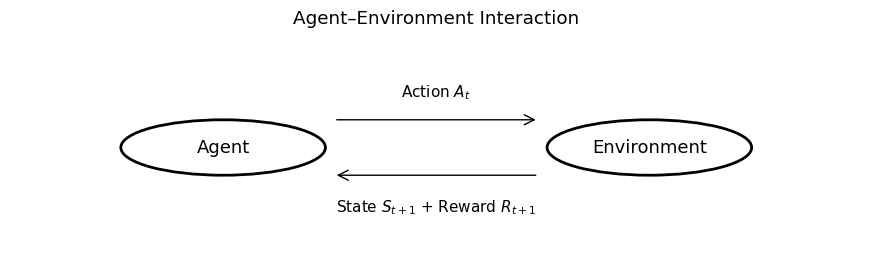

In [2]:

fig, ax = plt.subplots(figsize=(11, 3))

ax.axis("off")

agent = (0.25, 0.5)
environment = (0.75, 0.5)

ax.add_patch(
    Circle(agent, 0.12, fill=False, linewidth=2)
)

ax.add_patch(
    Circle(environment, 0.12, fill=False, linewidth=2)
)

ax.text(
    agent[0],
    agent[1],
    "Agent",
    ha="center",
    va="center",
    fontsize=13
)

ax.text(
    environment[0],
    environment[1],
    "Environment",
    ha="center",
    va="center",
    fontsize=13
)

# Action arrow
ax.add_patch(
    FancyArrowPatch(
        (0.38, 0.62),
        (0.62, 0.62),
        arrowstyle="->",
        mutation_scale=18
    )
)

ax.text(
    0.5,
    0.72,
    r"Action $A_t$",
    ha="center"
)

# State + reward arrow
ax.add_patch(
    FancyArrowPatch(
        (0.62, 0.38),
        (0.38, 0.38),
        arrowstyle="->",
        mutation_scale=18
    )
)

ax.text(
    0.5,
    0.22,
    r"State $S_{t+1}$ + Reward $R_{t+1}$",
    ha="center"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.title("Agent–Environment Interaction")
plt.show()



# 2. Policy

A **policy** describes how an agent chooses actions.

For a stochastic policy:

$$
\pi(a|s)
=
P(A_t=a|S_t=s)
$$

This means:

> If the agent is in state $s$, what is the probability of choosing action $a$?

A deterministic policy selects one action with probability 1.


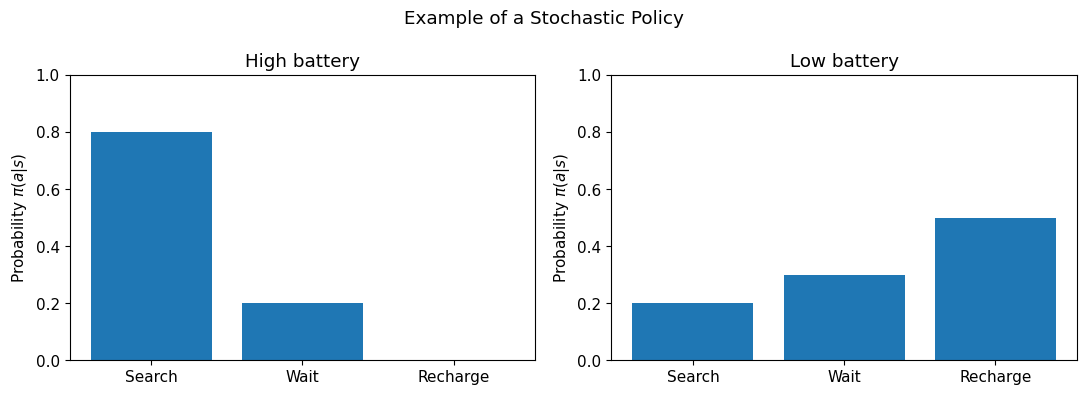

In [3]:

states = ["High battery", "Low battery"]

actions = [
    "Search",
    "Wait",
    "Recharge"
]

policy = {
    "High battery": [0.8, 0.2, 0.0],
    "Low battery": [0.2, 0.3, 0.5]
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, state in zip(axes, states):

    ax.bar(
        actions,
        policy[state]
    )

    ax.set_ylim(0, 1)

    ax.set_title(state)

    ax.set_ylabel(
        r"Probability $\pi(a|s)$"
    )

plt.suptitle(
    "Example of a Stochastic Policy"
)

plt.tight_layout()

plt.show()



# 3. States, Actions, and Rewards

## Example: Bioreactor

A possible state representation is:

$$
S_t =
[
\\text{sensor reading},
\\text{temperature reading}
]
$$

A possible action representation is:

$$
A_t =
[
\\text{target temperature},
\\text{stirring rate}
]
$$

The reward may represent the amount of useful chemical produced.

---

## Example: Pick-and-Place Robot

- **State:** joint angles and angular velocities.
- **Action:** motor voltages.
- **Reward:** successful placement of an object.

The reward is the mathematical signal used to communicate the objective to the agent.



# 4. Reward vs Return

The immediate reward is:

$$
R_{t+1}
$$

The **return** is the cumulative future reward.

For an episodic task:

$$
G_t
=
R_{t+1}
+
R_{t+2}
+
\\cdots
+
R_T
$$

The goal of Reinforcement Learning is usually to maximize **long-term return**, not simply immediate reward.


Rewards:
[ 1  0  2 -1  3]

Total return G_0:
5


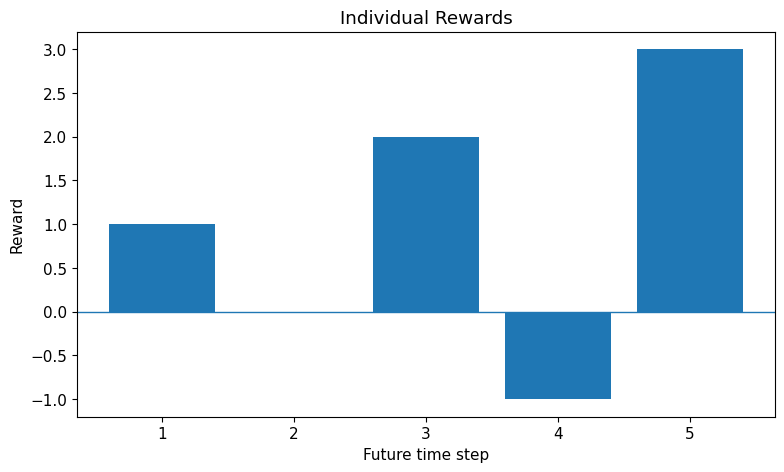

In [4]:

rewards = np.array([
    1,
    0,
    2,
    -1,
    3
])

print("Rewards:")
print(rewards)

print()

print("Total return G_0:")
print(rewards.sum())

plt.bar(
    np.arange(1, len(rewards) + 1),
    rewards
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel(
    "Future time step"
)

plt.ylabel(
    "Reward"
)

plt.title(
    "Individual Rewards"
)

plt.show()



# 5. Episodic vs Continuing Tasks

## Episodic Task

An episodic task has a natural ending.

Examples:

- Chess
- Maze solving
- Pole balancing

For episodic tasks:

$$
G_t
=
\\sum R
$$

---

## Continuing Task

A continuing task can continue indefinitely.

Examples:

- Robot operation
- Industrial control
- Stock management

For these tasks, we usually use a **discounted return**.



# 6. Discounted Return

For a continuing task:

$$
G_t
=
R_{t+1}
+
\\gamma R_{t+2}
+
\\gamma^2 R_{t+3}
+
\\cdots
$$

where:

$$
0
\\leq
\\gamma
<
1
$$

Interpretation:

- $\gamma = 0$: only immediate rewards matter.
- Small $\gamma$: strong preference for immediate rewards.
- $\gamma$ close to 1: future rewards become important.

A reward $k$ steps into the future receives weight:

$$
\\gamma^k
$$


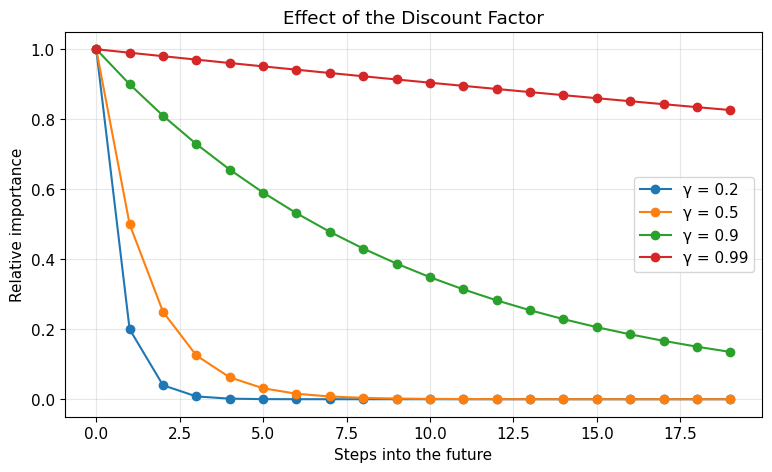

In [5]:

gamma_values = [
    0.2,
    0.5,
    0.9,
    0.99
]

steps = np.arange(0, 20)

for gamma in gamma_values:

    plt.plot(
        steps,
        gamma ** steps,
        marker="o",
        label=f"γ = {gamma}"
    )

plt.xlabel(
    "Steps into the future"
)

plt.ylabel(
    "Relative importance"
)

plt.title(
    "Effect of the Discount Factor"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


In [6]:

def discounted_return(rewards, gamma):

    total = 0

    for k, reward in enumerate(rewards):

        total += (
            gamma ** k
        ) * reward

    return total


example_rewards = [
    0,
    0,
    -1
]

for gamma in [
    0.2,
    0.5,
    0.9,
    0.99
]:

    value = discounted_return(
        example_rewards,
        gamma
    )

    print(
        f"γ = {gamma:.2f}"
        f" -> Return = {value:.6f}"
    )


γ = 0.20 -> Return = -0.040000
γ = 0.50 -> Return = -0.250000
γ = 0.90 -> Return = -0.810000
γ = 0.99 -> Return = -0.980100



# 7. The Markov Property

The Markov property is one of the most important concepts in Reinforcement Learning.

A state is Markov if the current state contains enough information to predict the future.

Mathematically:

$$
P(
S_{t+1}=s',
R_{t+1}=r
|
S_t,
A_t,
\\text{past}
)
$$

$$
=
P(
S_{t+1}=s',
R_{t+1}=r
|
S_t,
A_t
)
$$

In simple words:

> Once we know the current state and action, we do not need the complete history.

---

## Example

For a moving object:

$$
S_t =
[
\\text{position},
\\text{velocity}
]
$$

Position alone may not be enough because velocity affects what happens next.


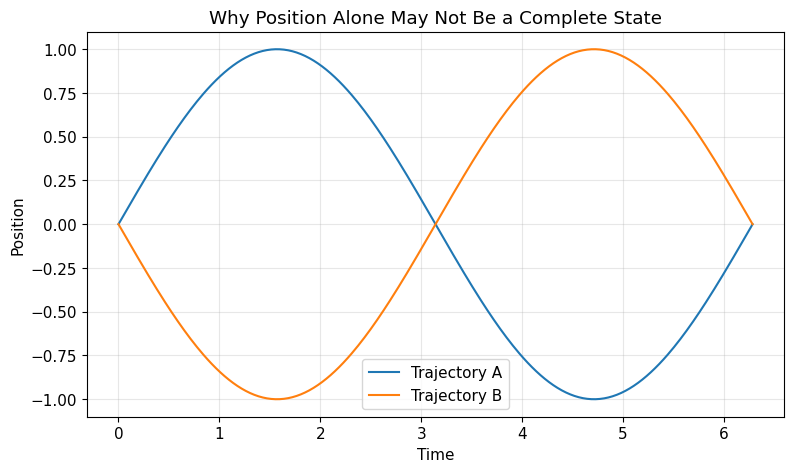

The same position can occur while an object moves in different directions.
Therefore velocity may also be needed in the state.


In [7]:

t = np.linspace(
    0,
    2 * np.pi,
    300
)

trajectory_A = np.sin(t)

trajectory_B = np.sin(
    t + np.pi
)

plt.plot(
    t,
    trajectory_A,
    label="Trajectory A"
)

plt.plot(
    t,
    trajectory_B,
    label="Trajectory B"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Position"
)

plt.title(
    "Why Position Alone May Not Be a Complete State"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

print(
    "The same position can occur while an object moves "
    "in different directions."
)

print(
    "Therefore velocity may also be needed in the state."
)



# 8. Markov Decision Process

A Markov Decision Process is commonly represented as:

$$
\mathcal{M}
=
(
\mathcal{S},
\mathcal{A},
P,
R,
\\gamma
)
$$

where:

- $\mathcal{S}$ = state space
- $\mathcal{A}$ = action space
- $P$ = transition dynamics
- $R$ = reward function
- $\gamma$ = discount factor

---

## Transition Probability

$$
P(
s'
|
s,
a
)
=
P(
S_{t+1}=s'
|
S_t=s,
A_t=a
)
$$

This answers:

> If I am currently in state $s$ and take action $a$, what is the probability of reaching $s'$?



# 9. Expected Reward

The expected reward for a state-action pair is:

$$
r(s,a)
=
\mathbb{E}
[
R_{t+1}
|
S_t=s,
A_t=a
]
$$

A more detailed reward model is:

$$
r(s,a,s')
=
\mathbb{E}
[
R_{t+1}
|
S_t=s,
A_t=a,
S_{t+1}=s'
]
$$

The second expression is more detailed because it describes the reward for a specific transition.



# 10. Recycling Robot Example

The robot has two battery states:

$$
\mathcal{S}
=
\{
High,
Low
\}
$$

Actions:

- Search
- Wait
- Recharge

We define:

- $\alpha$: probability that searching from High leaves the battery High.
- $\beta$: probability that searching from Low leaves the battery Low.


In [8]:

alpha = 0.7

beta = 0.6

r_search = 3

r_wait = 1

r_rescue = -3


transitions = [

    (
        "High",
        "Search",
        "High",
        alpha,
        r_search
    ),

    (
        "High",
        "Search",
        "Low",
        1 - alpha,
        r_search
    ),

    (
        "Low",
        "Search",
        "Low",
        beta,
        r_search
    ),

    (
        "Low",
        "Search",
        "High",
        1 - beta,
        r_rescue
    ),

    (
        "High",
        "Wait",
        "High",
        1.0,
        r_wait
    ),

    (
        "Low",
        "Wait",
        "Low",
        1.0,
        r_wait
    ),

    (
        "Low",
        "Recharge",
        "High",
        1.0,
        0
    )
]


print(
    "State | Action | Next State | Probability | Reward"
)

print(
    "-" * 60
)


for row in transitions:

    print(
        f"{row[0]:6} | "
        f"{row[1]:8} | "
        f"{row[2]:10} | "
        f"{row[3]:11.2f} | "
        f"{row[4]:6}"
    )


State | Action | Next State | Probability | Reward
------------------------------------------------------------
High   | Search   | High       |        0.70 |      3
High   | Search   | Low        |        0.30 |      3
Low    | Search   | Low        |        0.60 |      3
Low    | Search   | High       |        0.40 |     -3
High   | Wait     | High       |        1.00 |      1
Low    | Wait     | Low        |        1.00 |      1
Low    | Recharge | High       |        1.00 |      0



# 11. Checking Transition Probabilities

For every state-action pair:

$$
\sum_{s'}
P(s'|s,a)
=
1
$$

Let's verify this using Python.


In [9]:

from collections import defaultdict


probability_sums = defaultdict(float)


for (
    state,
    action,
    next_state,
    probability,
    reward
) in transitions:

    probability_sums[
        (state, action)
    ] += probability


for (
    state,
    action
), total in probability_sums.items():

    print(
        f"{state}, {action}"
        f" -> probability sum = "
        f"{total:.2f}"
    )


High, Search -> probability sum = 1.00
Low, Search -> probability sum = 1.00
High, Wait -> probability sum = 1.00
Low, Wait -> probability sum = 1.00
Low, Recharge -> probability sum = 1.00



# 12. Simulating the Recycling Robot

We will use the following simple policy:

- High battery → Search
- Low battery → Recharge

This is only an example policy.
It is not necessarily optimal.


In [10]:

rng = np.random.default_rng(
    42
)


def simulate_robot(
    steps=30,
    alpha=0.7,
    beta=0.6
):

    state = "High"


    policy = {

        "High": "Search",

        "Low": "Recharge"

    }


    history = []


    for t in range(steps):

        action = policy[state]


        if (
            state == "High"
            and
            action == "Search"
        ):

            if rng.random() < alpha:

                next_state = "High"

            else:

                next_state = "Low"


            reward = r_search


        elif (
            state == "Low"
            and
            action == "Recharge"
        ):

            next_state = "High"

            reward = 0


        history.append(

            (
                t,
                state,
                action,
                reward,
                next_state
            )

        )


        state = next_state


    return history


history = simulate_robot()


print(
    "t | State | Action | Reward | Next State"
)

print(
    "-" * 50
)


for row in history[:15]:

    print(
        f"{row[0]:2} | "
        f"{row[1]:5} | "
        f"{row[2]:8} | "
        f"{row[3]:6} | "
        f"{row[4]}"
    )


t | State | Action | Reward | Next State
--------------------------------------------------
 0 | High  | Search   |      3 | Low
 1 | Low   | Recharge |      0 | High
 2 | High  | Search   |      3 | High
 3 | High  | Search   |      3 | Low
 4 | Low   | Recharge |      0 | High
 5 | High  | Search   |      3 | High
 6 | High  | Search   |      3 | High
 7 | High  | Search   |      3 | Low
 8 | Low   | Recharge |      0 | High
 9 | High  | Search   |      3 | Low
10 | Low   | Recharge |      0 | High
11 | High  | Search   |      3 | Low
12 | Low   | Recharge |      0 | High
13 | High  | Search   |      3 | High
14 | High  | Search   |      3 | High


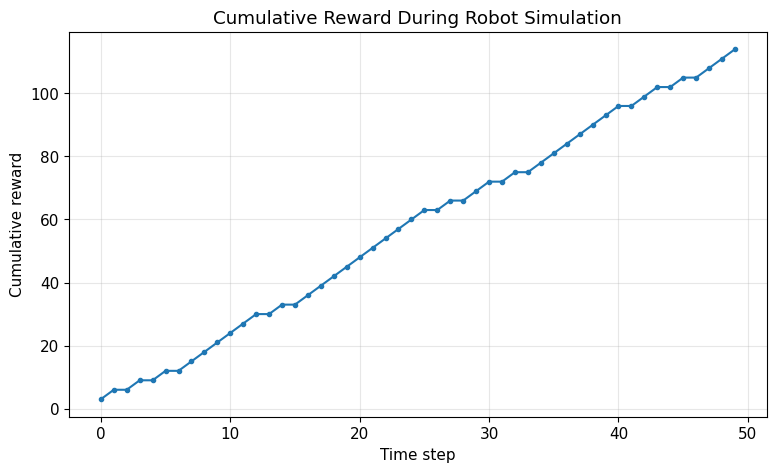

Total reward: 114


In [11]:

history = simulate_robot(
    steps=50
)


rewards = np.array(

    [
        row[3]
        for row in history
    ]

)


cumulative_rewards = np.cumsum(
    rewards
)


plt.plot(
    cumulative_rewards,
    marker="o",
    markersize=3
)


plt.xlabel(
    "Time step"
)


plt.ylabel(
    "Cumulative reward"
)


plt.title(
    "Cumulative Reward During Robot Simulation"
)


plt.grid(
    alpha=0.3
)


plt.show()


print(
    "Total reward:",
    cumulative_rewards[-1]
)



# 13. Immediate vs Delayed Rewards

Consider two reward sequences:

### Sequence A

$$
[5,0,0,0,0]
$$

### Sequence B

$$
[0,0,0,0,8]
$$

The discount factor $\gamma$ determines which sequence is preferred.


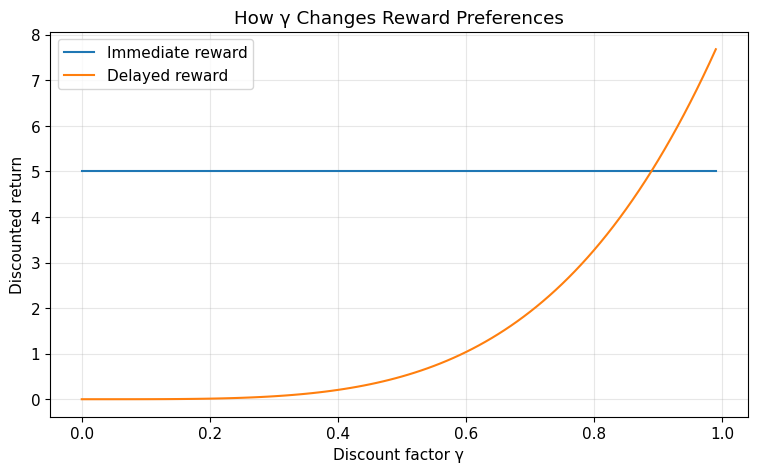

In [12]:

sequence_A = [
    5,
    0,
    0,
    0,
    0
]


sequence_B = [
    0,
    0,
    0,
    0,
    8
]


gammas = np.linspace(
    0,
    0.99,
    100
)


values_A = [

    discounted_return(
        sequence_A,
        gamma
    )

    for gamma in gammas

]


values_B = [

    discounted_return(
        sequence_B,
        gamma
    )

    for gamma in gammas

]


plt.plot(
    gammas,
    values_A,
    label="Immediate reward"
)


plt.plot(
    gammas,
    values_B,
    label="Delayed reward"
)


plt.xlabel(
    "Discount factor γ"
)


plt.ylabel(
    "Discounted return"
)


plt.title(
    "How γ Changes Reward Preferences"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.show()



# 14. Final Summary

The Reinforcement Learning interaction is:

$$
\boxed{
S_t
\\xrightarrow{\\text{policy}}
A_t
\\xrightarrow{\\text{environment}}
(R_{t+1},S_{t+1})
}
$$

The agent tries to maximize return.

For episodic tasks:

$$
\boxed{
G_t
=
\\sum R
}
$$

For continuing tasks:

$$
\boxed{
G_t
=
\\sum_{k=0}^{\\infty}
\\gamma^k
R_{t+k+1}
}
$$

The Markov property means:

$$
\boxed{
\\text{The current state contains enough information to predict the next step.}
}
$$

## Most Important Takeaway

A major challenge in Reinforcement Learning is choosing a good **state representation**.

If the state contains the important information needed to make decisions, the problem can often be modeled effectively as a Markov Decision Process.
